# 04. Analysis and Visualization

This notebook analyzes the **Developer Supply** side by using the aggregated data from **StackOverflow** and **GitHub** (filtered from the unified dataset).

## Goals
1.  Load the unified `merged_supply_data.csv`.
2.  Filter for Supply data (exclude Job postings).
3.  Analyze the distribution of domains (e.g., Web Backend, Data AI).
4.  Analyze the popularity of programming languages/technologies within each domain.
5.  Visualize trends over time.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [17]:
df_all = pd.read_csv('data/outputs/Final_Dataset_Label.csv')

# Filter for Supply Data (StackOverflow + GitHub)
# source_type is 'stackoverflow', 'github', or 'job'
df_supply = df_all[df_all['source_type'] != 'job'].copy()

print(f"Total Rows: {len(df_all)}")
print(f"Supply Rows (SO + GitHub): {len(df_supply)}")
df_supply.head()

Total Rows: 15917
Supply Rows (SO + GitHub): 15917


,source_type,raw_text,language,label_gemini,label_gpt,label,event_date
0,jobs,senior software engineer security clearance se...,"c, c++",security,security,security,2024
1,jobs,associate software engineer description makemy...,"c#, javascript",web frontend,web frontend,web frontend,2025
2,jobs,ruby rails developer position rails developer ...,"c, go",web backend,web backend,web backend,2025
3,jobs,full stack developer synechron inc seeking jav...,"java, javascript, typescript",web frontend,web backend,web backend,2025
4,jobs,implementation lead guidewire integration lead...,javascript,web frontend,web frontend,web frontend,2024


## 2. Analysis: Domain Distribution
What domains are developers most active in?

/tmp/ipykernel_66018/379402940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, palette='viridis')


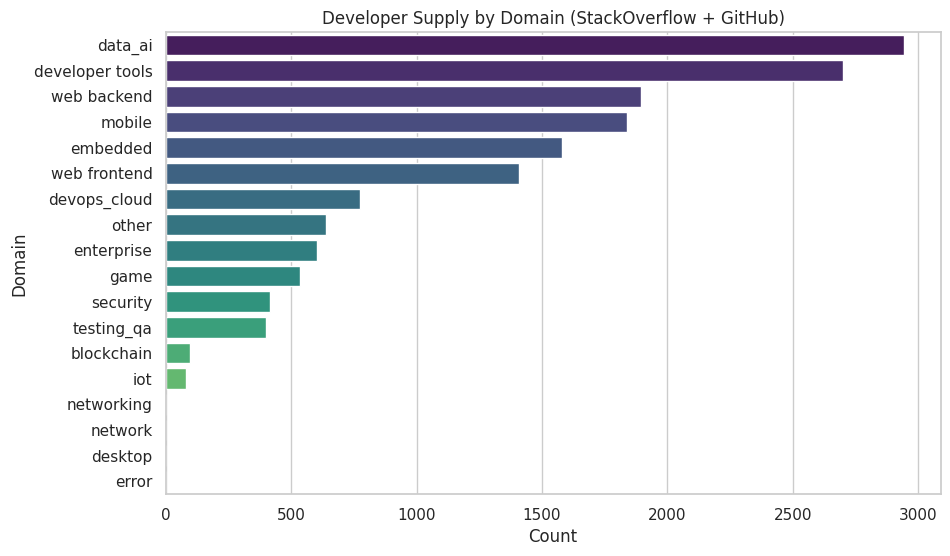

In [18]:
domain_counts = df_supply['label'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.values, y=domain_counts.index, palette='viridis')
plt.title('Developer Supply by Domain (StackOverflow + GitHub)')
plt.xlabel('Count')
plt.ylabel('Domain')
plt.show()

## 3. Analysis: Languages per Domain
What languages are dominating each domain?

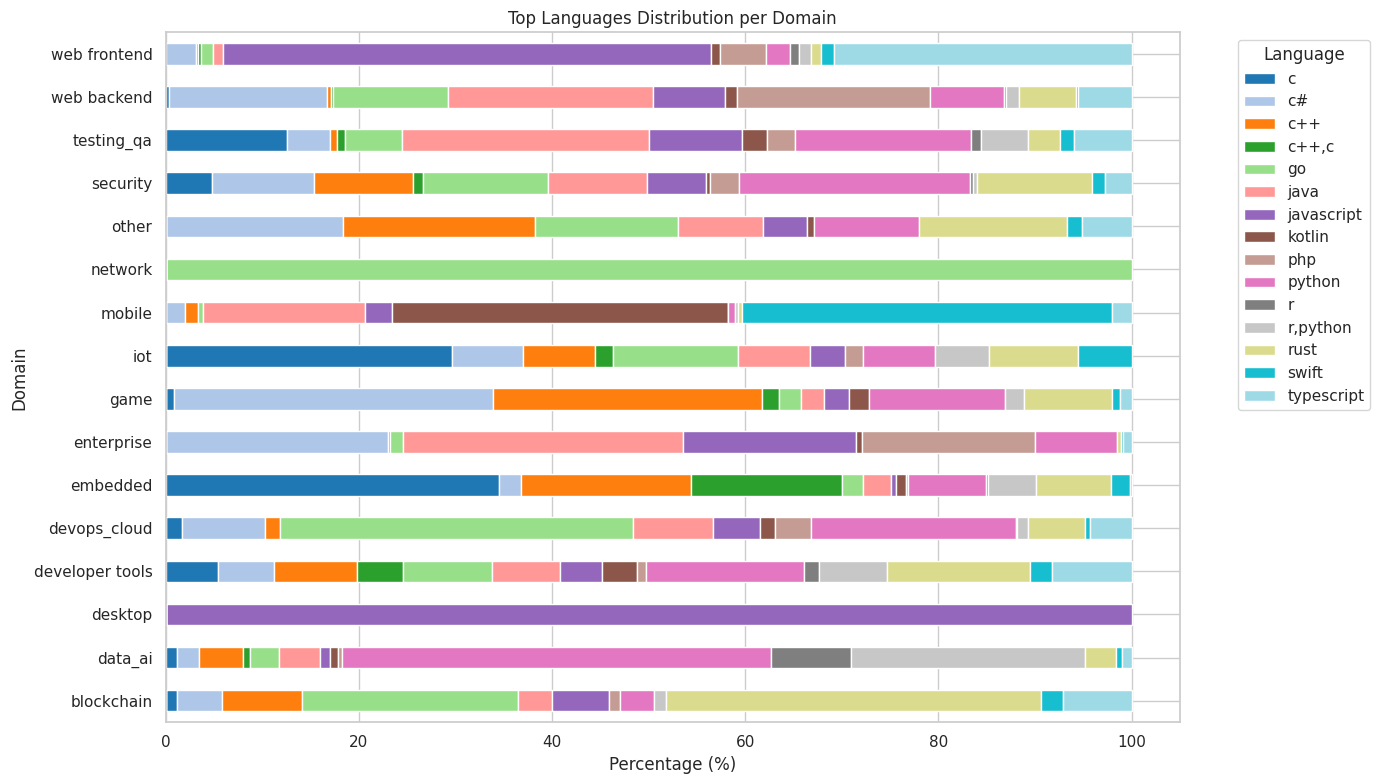

In [19]:
# Filter for top languages to keep charts readable
top_langs = df_supply['language'].value_counts().nlargest(15).index
df_top = df_supply[df_supply['language'].isin(top_langs)]

# Cross-tabulation
ct = pd.crosstab(df_top['label'], df_top['language'], normalize='index') * 100

# Plot
ct.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Top Languages Distribution per Domain')
plt.xlabel('Percentage (%)')
plt.ylabel('Domain')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Trend Analysis (Over Time)
How has activity changed over the years?

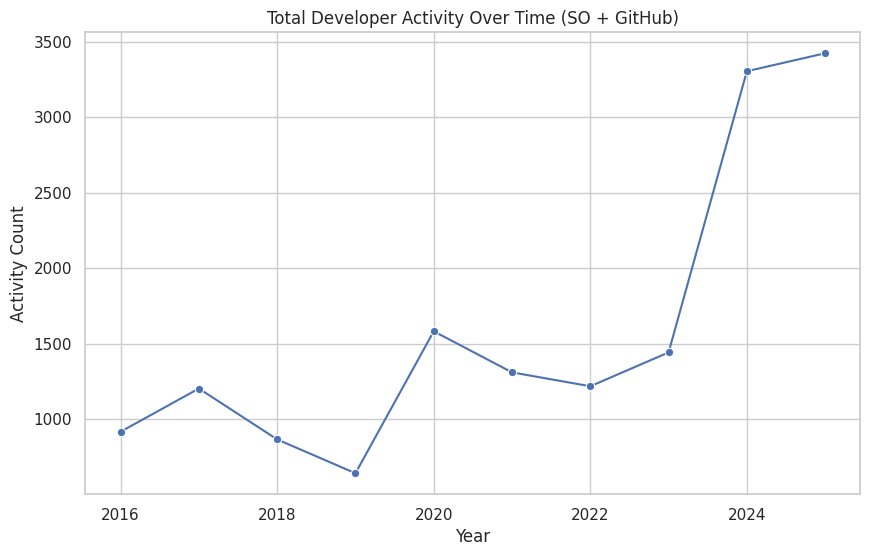

In [20]:
df_Supply_Time = df_supply.copy()
df_Supply_Time['year'] = pd.to_numeric(df_Supply_Time['event_date'], errors='coerce')

df_Supply_Time = df_Supply_Time.dropna(subset=['year'])
df_Supply_Time['year'] = df_Supply_Time['year'].astype(int)

# Count by Year
year_counts = df_Supply_Time['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Total Developer Activity Over Time (SO + GitHub)')
plt.xlabel('Year')
plt.ylabel('Activity Count')
plt.show()